# Data Exploration Report - for "RAGuardianNews" Prototype
IDS 570 - Text as Data\
Peter de Guzman ped19\
02/26/26

# Table of Contents
* [Project Overview](#project-overview)
    * [Description of Data](#description-of-data)
* [Data Pipeline and Application Functionality](#data-pipeline-and-application-functionality)
    * [Data Pre-processing Procedures](#data-pre-processing-procedures)
* [Metadata Analysis](#metadata-analysis)
* [Measures of Lexican Distinctiveness, Similarity, and Syntactic Complexity](#measures-of-lexical-distinctiveness-similarity-and-syntactic-complexity)
    * [TF-IDF Analysis](#tf-idf-analysis)
    * [Pearson Correlation](#pearson-correlation)
    * [Syntactic Complexity Measures](#syntactic-complexity-measures)
* [Synthesis of Findings](#synthesis-of-findings)
* [Appendix](#appendix)

<h2 id="project-overview">Project Overview</h2>

This project aims to perform Named Entity Recognition (NER) and leverage Retrieval Augmented Generation (RAG) to allow users to easily query articles from **The Guardian** (a British daily newspaper) regarding artificial intelligence using natural language. Users will be able to enter in a question or topic and the system will find relevant articles and summarize key information or answer the specific query using large language models (LLMs).

Note: This report will focus only on the initial steps of data collection (Extract, Transform, and Load) and a meta-analysis of the dataset.

<h3 id="description-of-data">Description of Data</h2>

For this project, news articles were downloaded from the Guardian API for the time period of `2016-02-22` to `2026-02-22`. The 10 year period was chosen for this pilot project to collect a large number of articles while still avoiding rate limitations when downloading articles through the API. The 10 year period allowed for the inclusion of articles from before the release of GPT-1 & BERT in 2018, and the widespread adoption of ChatGPT between 2020-2022. The query terms used for the API keyword search were "artificial intelligence", "AI", "generative AI", and "GenAI". These search terms were chosen for this prototype to capture the rice in AI technologies while being more narrow than simply downloading articles related to "technology". The 'q' query parameter used with the API ensures that the API call only returns content that explicitly includes the keyword search term. 

The resulting dataset is 24,124 articles, which was downloaded from the API and saved in a JSON file format. 

<h2 id="data-pipeline">Data Pipeline</h2>


<h3 id="data-pipeline-and-application-functionality">Data Pipeline and Application Functionality</h2>

```mermaid
flowchart LR
    %% Data ingestion
    API["API"]:::ingest --> DB_RAW["DuckDB (Raw Articles)"]:::storage

    %% Transformation with dbt
    DB_RAW -->|dbt run| DB_CLEAN["DuckDB (Cleaned Articles)"]:::storage

    %% NLP / downstream
    DB_CLEAN --> NER["NER Extraction"]:::process
    NER --> RAG["RAG Embeddings / QA"]:::process

    %% Final query
    RAG --> LLM["LLM Query"]:::query

    %% Feedback loops
    LLM -- Feedback / Updates --> RAG
    LLM -- Feedback / Updates --> NER

    %% Style definitions
    classDef ingest fill:#a2d2ff,stroke:#0d3b66,stroke-width:1px,color:#0d3b66
    classDef storage fill:#ffb703,stroke:#fb8500,stroke-width:1px,color:#000000
    classDef process fill:#8ac926,stroke:#3f681c,stroke-width:1px,color:#000000
    classDef query fill:#9d4edd,stroke:#6a0dad,stroke-width:1px,color:#ffffff
```

<h3 id="data-pre-processing-procedures">Data Pre-processing Procedures</h3>

Data Transformation with `dbt`:

Once articles were downloaded, they were de-duplicated by the "id". Because I did not implement a ranking algorithm for this de-duplication, if the same article was downloaded under multiple search terms, the last search term was retained. This is a limitation to this approach because the resulting dataset was heavily imbalanced and 99% of the retained articles were assigned search terms "artificial intelligence" or "generative AI".. It is possible that there was overlap in articles and search terms, but this process was chosen due to timeline and rate limitation constraints. An improvement to this analysis would incorporate a method for accounting for articles that appeared under multiple search terms and flag this attribute, while retaining the maximum amount of information per article. 

From the JSON file, articles are loaded into a DuckDB database and saved in the `raw_articles` table. To clean the body text of the articles and prepare them for analysis, the `cleaned_articles.sql` dbt model was written which points to the `raw_articles` table and removes all HTML tags from the body text column before saving it as 'clean_body'. I decided to not remove the time stamps (such as '8.31 BST') that were observed because some articles that possess these time stamps are live updates while others represent back and forth dialogues. Therefore, the time stamps provide information regarding the structure of the article and possess inherent meaning. It is possible that at a later date it may be helpful to remove these time stamps from the cleaned dataset if they are adding additional noise to our analysis and are not useful. 

Tests are also implemented with `dbt` to check that all values for id and the body text are unique and not null in the `cleaned_articles` and `sample_articles` tables. These tests can be implemented by navigating to the `dbt_guardian/` folder and running the `uv run dbt test` command. 

<h2 id="metadata-analysis">Metadata Analysis</h2>


Once the data is extracted from the Guardian API, loaded into the DuckDB database and transformed into a cleaned dataset, we are able to analyze the metadata to review its completeness over the years and trends over time by its various features. 

The columns present in the cleaned table include: ['id', 'type', 'sectionId', 'sectionName', 'webPublicationDate', 'webTitle', 'webUrl', 'apiUrl', 'body', 'isHosted', 'pillarId', 'pillarName', 'headline', 'shortUrl', 'search_term', 'pull_date', 'clean_body'].
- The API call includes a parameter "isHosted" which is "false" if the article is regular *The Guardian* editorial content that is produced by their newsroom and "true" if it is sponsored content or content produced in partnership with another organization. None of the articles in this dataset were marked as sponsored content. 
- The "pillar" classification system is a topical distinction in articles, with categories such as "News", "Opinion", "Sports", "Arts", "Lifestyle". The distribution of these topics is displayed below.
- The "section" classification denotes as specific desk that the article was published under, and is more granular. The distribution of these sections is also displayed below. 

Overall, despite the breadth of the ten year period of news articles the metadata was very complete. The only variables that possessed any missing data were "pillarName" and "pillarId", which both were missing from only 0.94% of observations. Since the "pillar" represent the topic, "pillarName" is a subset of "pillarId". For example, an article from the "News" pillar would have the "pillarId" of "pillar/news" and the "pillarName" value would be represented as "News". 

In [170]:
import duckdb
import pandas as pd

In [171]:
con = duckdb.connect("../guardian_articles.duckdb")

In [172]:
# load table
df = con.execute("SELECT * FROM cleaned_articles").fetchdf()

# compute missing counts and percentages
missing_summary = pd.DataFrame(
    {"missing_count": df.isna().sum(), "missing_pct": 100 * df.isna().mean()}
).sort_values(by="missing_pct", ascending=False)

print(missing_summary)

                    missing_count  missing_pct
pillarName                    227     0.940972
pillarId                      227     0.940972
id                              0     0.000000
isHosted                        0     0.000000
pull_date                       0     0.000000
search_term                     0     0.000000
shortUrl                        0     0.000000
headline                        0     0.000000
body                            0     0.000000
type                            0     0.000000
apiUrl                          0     0.000000
webUrl                          0     0.000000
webTitle                        0     0.000000
webPublicationDate              0     0.000000
sectionName                     0     0.000000
sectionId                       0     0.000000
clean_body                      0     0.000000


In [173]:
pd.crosstab(
    df["pillarName"].isna(),
    df["pillarId"].isna(),
    rownames=["pillarName_missing"],
    colnames=["pillarId_missing"],
)

pillarId_missing,False,True
pillarName_missing,,
False,23897,0
True,0,227


All 224 observations that were missing "pillarId" were also missing "pillarName". 

In [174]:
# counts by type
counts = df["type"].value_counts()
shares = df["type"].value_counts(normalize=True)

summary = pd.concat([counts, shares], axis=1)
summary.columns = ["count", "share"]

print(summary)

             count     share
type                        
article      22095  0.915893
liveblog      1903  0.078884
interactive    122  0.005057
audio            3  0.000124
picture          1  0.000041


Nearly all (92%) of the individual observations of content downloaded from *The Guardian* API were articles, while 8% were live blogs. A small share (~0.5%) were interactive media, audio format, or pictures.

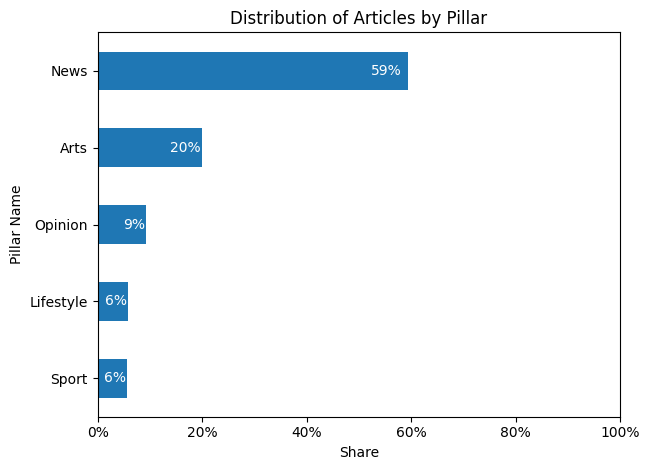

In [175]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Calculate shares
shares = df["pillarName"].value_counts(normalize=True, dropna=True)

# Sort for horizontal bar chart
shares = shares.sort_values()

plt.figure()
ax = shares.plot(kind="barh")

plt.xlabel("Share")
plt.ylabel("Pillar Name")
plt.title("Distribution of Articles by Pillar")


# data labels
for i, v in enumerate(shares):
    ax.text(
        v * 0.98,
        i,
        f"{v:.0%}",
        va="center",
        ha="right",
        color="white",
    )

plt.tight_layout()
# fixing a axis labels and limits
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlim(0, 1)

plt.show()

When analyzing the contents of our corpus by "pillar" or topic, we see that nearly six in ten (59%) of articles were published with the "News" classification. 20% were published with "Arts", 9% with "Opinion", and 6% with "Lifestyle" and "Sport" classifications. These represent all the present values for "pillarName" in the dataset.

Drilling down into the more granular category of "section", we see that there are many more unique values (84) for "sectionName" than there are for "pillarName" (There are 5 unique categories for "pillarName"). Below, we see that the only unique "sectionName" that represents over 10% of the articles in our corpus is "Technology", which accounts for 12% of articles. One note is that *The Guardian*'s Opinion section was previously titled "Comment is Free", after a quote by the 1921 Guardian editor CP Scott "Comment is free...but facts are sacred." In the `sample_articles` dataframe used for the second part of this analysis there is an article that was published under this section with a corresponding "sectionName" value of "commentisfree".

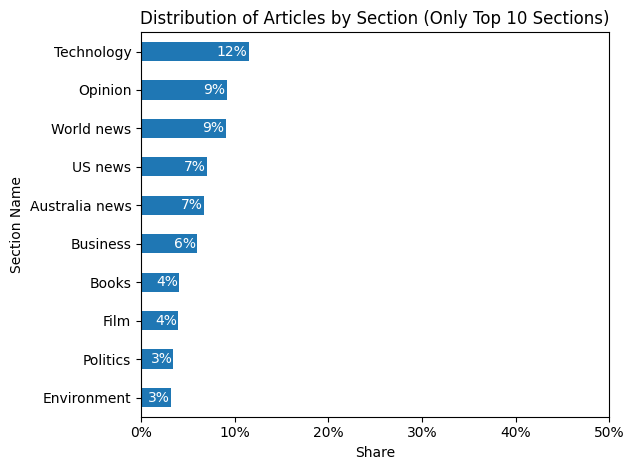

In [177]:
# Calculate shares
shares = (
    df["sectionName"].value_counts(normalize=True, dropna=True).head(10).sort_values()
)
# Sort for horizontal bar chart
shares = shares.sort_values().head(10)

plt.figure()
ax = shares.plot(kind="barh")

plt.xlabel("Share")
plt.ylabel("Section Name")
plt.title("Distribution of Articles by Section (Only Top 10 Sections)")


# data labels
for i, v in enumerate(shares):
    ax.text(
        v * 0.98,
        i,
        f"{v:.0%}",
        va="center",
        ha="right",
        color="white",
    )

plt.tight_layout()
# fixing a axis labels and limits
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlim(0, 0.5)

plt.show()

In the figure below, we can see that after filtering our corpus to only articles under the "News" pillar, one in five (20%) of articles were assigned the "Technology" section name. None of the articles were assigned the section name of "Opinion", as "Opinion" pieces and "News" pieces (as categorized by pillar name or section name) were mutually exclusive categorizations. However, it was noteworthy that the mentions of "artificial intelligence" and "generative AI" were not solely concentrated among "News" articles published in the "Technology" section, but were present in a wide range of sections including categories that concerned geopolitical, environmental, economic, and societal topics. 

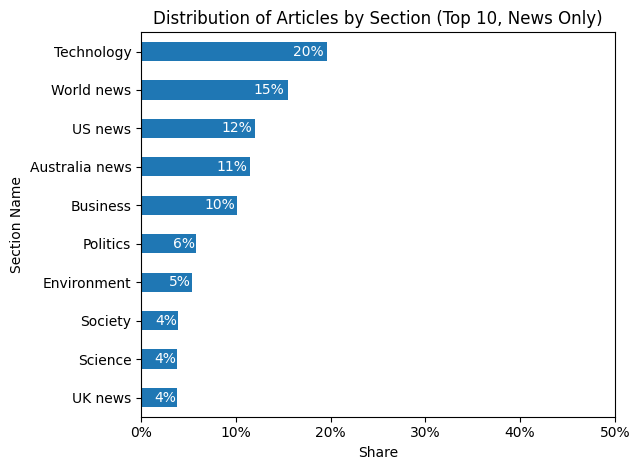

In [178]:
# Filter to News only
df_news = df[df["pillarName"] == "News"]

# Calculate shares (top 10 sections within News)
shares = (
    df_news["sectionName"]
    .value_counts(normalize=True, dropna=True)
    .head(10)
    .sort_values()
)

plt.figure()
ax = shares.plot(kind="barh")

plt.xlabel("Share")
plt.ylabel("Section Name")
plt.title("Distribution of Articles by Section (Top 10, News Only)")

# Data labels
for i, v in enumerate(shares):
    ax.text(
        v * 0.98,
        i,
        f"{v:.0%}",
        va="center",
        ha="right",
        color="white",
    )

plt.tight_layout()

# Format axis as percent and set limits
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlim(0, 0.5)

plt.show()

When reviewing this corpus, it is informative to pay special attention to the distribution of articles concerning "artificial intelligence" and "generative AI" by the year in which they were published. In the below plot, we observe that there was a steady mention of articles concerning these technologies between 2016-2022 before a sharp increase in 2023 through 2025. 

This spike in mentions of artificial intelligence was likely due to the November 30, 2022 release of an early demo of ChatGPT by OpenAI (Forbes, 2023). Mentions of artificial intelligence and generative AI remained steady in 2024 before again increasing in 2025. As these terms have become salient topics in modern discussions of the economy, labor, environment, and society it is reasonable to expect that the 2026 number of mentions will be close to or exceed recent years. 

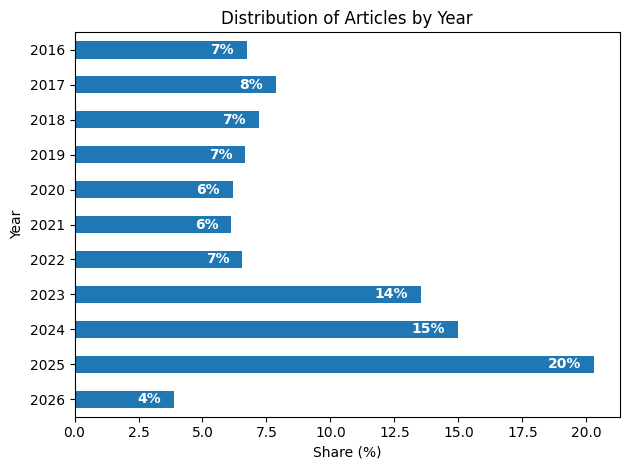

In [179]:
# plotting number of articles by year
df["webPublicationDate"] = pd.to_datetime(df["webPublicationDate"])
df["year"] = df["webPublicationDate"].dt.year
summary_year = df["year"].value_counts().sort_index(ascending=False).to_frame("Count")
summary_year["Share (%)"] = (
    summary_year["Count"] / summary_year["Count"].sum() * 100
).round(2)

plt.figure()
ax = summary_year["Share (%)"].plot(kind="barh")

plt.xlabel("Share (%)")
plt.ylabel("Year")
plt.title("Distribution of Articles by Year")

# data labels
for i, v in enumerate(summary_year["Share (%)"]):
    ax.text(
        v - 0.5,  # just inside the end of the bar
        i,
        f"{v:.0f}%",
        va="center",
        ha="right",
        color="white",
        fontweight="bold",
    )

plt.tight_layout()
ax.set_xlim(0, summary_year["Share (%)"].max() * 1.05)
plt.show()

One interesting difference can be seen when we facet the above plot by search term. In our corpus the distribution by year of articles with search term "artificial intelligence" is steady, with no clear pattern in variation. However, for articles with search term "generative AI", the distribution by year shows a much more marked increase in 2023, peaking in the most recent full year of articles (2025). This mirrors the above plot and shows that the more recent increase in articles that mention these topics is driven by "generative AI".

The term "artificial intelligence" was first used in the early 1950s by the computer scientist John McCarthy and his colleagues at the Dartmouth Conference (Haenlein & Kaplan 2019). Although generative AI concepts have existed since the development of generative neural networks in the early 2000s and the release of models such as the generative pre-trained transformer (or GPT) in 2018, this plot potentially indicates that this term may have been slightly more niche than artificial intelligence but is growing in popularity. 

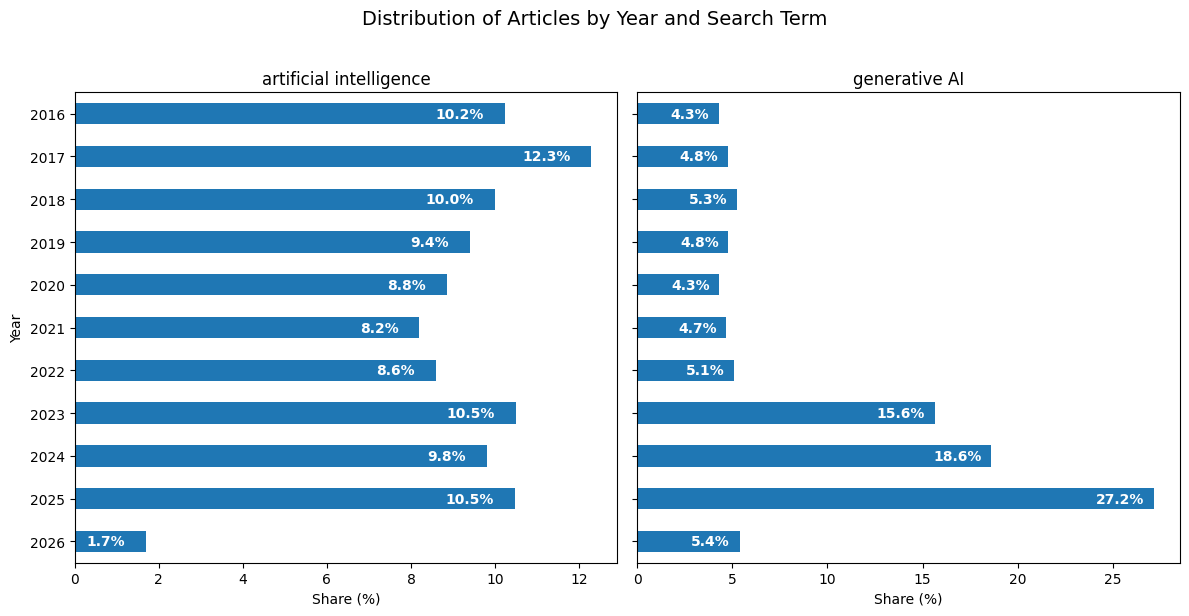

In [181]:
search_terms = df["search_term"].unique()
n = len(search_terms)

fig, axes = plt.subplots(1, n, figsize=(6 * n, 6), sharey=True)

for ax, term in zip(axes, search_terms):
    subset = df[df["search_term"] == term]
    summary = (
        subset["year"].value_counts().sort_index(ascending=False).to_frame("Count")
    )
    summary["Share (%)"] = (summary["Count"] / summary["Count"].sum() * 100).round(2)

    summary["Share (%)"].plot(kind="barh", ax=ax)

    for i, v in enumerate(summary["Share (%)"]):
        ax.text(
            v - 0.5,
            i,
            f"{v:.1f}%",
            va="center",
            ha="right",
            color="white",
            fontweight="bold",
        )

    ax.set_title(term)
    ax.set_xlabel("Share (%)")
    ax.set_ylabel("Year")
    ax.set_xlim(0, summary["Share (%)"].max() * 1.05)

plt.suptitle("Distribution of Articles by Year and Search Term", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [182]:
# close connection
con.close()

<h2 id="measures-of-lexical-distinctiveness-similarity-and-syntactic-complexity">Measures of Lexical Distinctiveness, Similarity, and Syntactic Complexity</h2>

<h3 id="tf-idf-analysis">TF-IDF Analysis</h3>


Before conducting additional analysis on the corpus, I randomly sampled articles from the corpus to create a subset of 10 articles found using the search term "artificial intelligence" and 10 articles found using the search term "generative AI". The resulting 20 articles were saved in the `sample_articles` table in DuckDB. I also created a `short_id` column to tag each article with a shorter ID containing their `sectionId` and an alphanumeric indicator for easier reference and more interpretable plots. 

In [183]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [184]:
con = duckdb.connect("../guardian_articles.duckdb")
df = con.execute("SELECT * FROM sample_articles").fetchdf()

In [186]:
# make sure sorted in a deterministic way
df = df.sort_values(["sectionId", "webPublicationDate"])
# rank within each section
df["section_rank"] = df.groupby("sectionId").cumcount() + 1
# convert rank to A01 format
df["short_code"] = "A" + df["section_rank"].astype(str).str.zfill(2)
# combine with sectionId
df["short_id"] = df["sectionId"] + "-" + df["short_code"]
# drop the helper cols that I added while creating short_id
df = df.drop(columns=["section_rank", "short_code"])

To conduct TF-IDF, I used the `sklearn` package's `TfidfVectorizer` functionality. This class is very helpful because it combines CountVectorizer and TfidfTransformer to directly convert the raw text documents (in this case, the cleaned body text of the articles) into a matrix of TF-IDF features. This simplifies our pre-processing pipeline. I decided to use the included english stop words list that is included in the `sklearn.feature_extraction` source code, which originally is sourced from the Glasgow Information Retrieval Group (linked in the Appendix). Although this list of over 300 English stop words may require future editing, for the purpose of this preliminary data exploration I determined it was sufficient to filter out words that would likely not carry much semantic meaning within the articles. 

In [ ]:
# computing TF-IDF
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.9, min_df=1)

tfidf_matrix = vectorizer.fit_transform(df["clean_body"])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=df["short_id"],
)

# print(tfidf_df.shape)

Using the TF-IDF matrix generated through the `TfidfVectorizer` class, we can view the top 10 words in each document that had the highest TF-IDF score. 

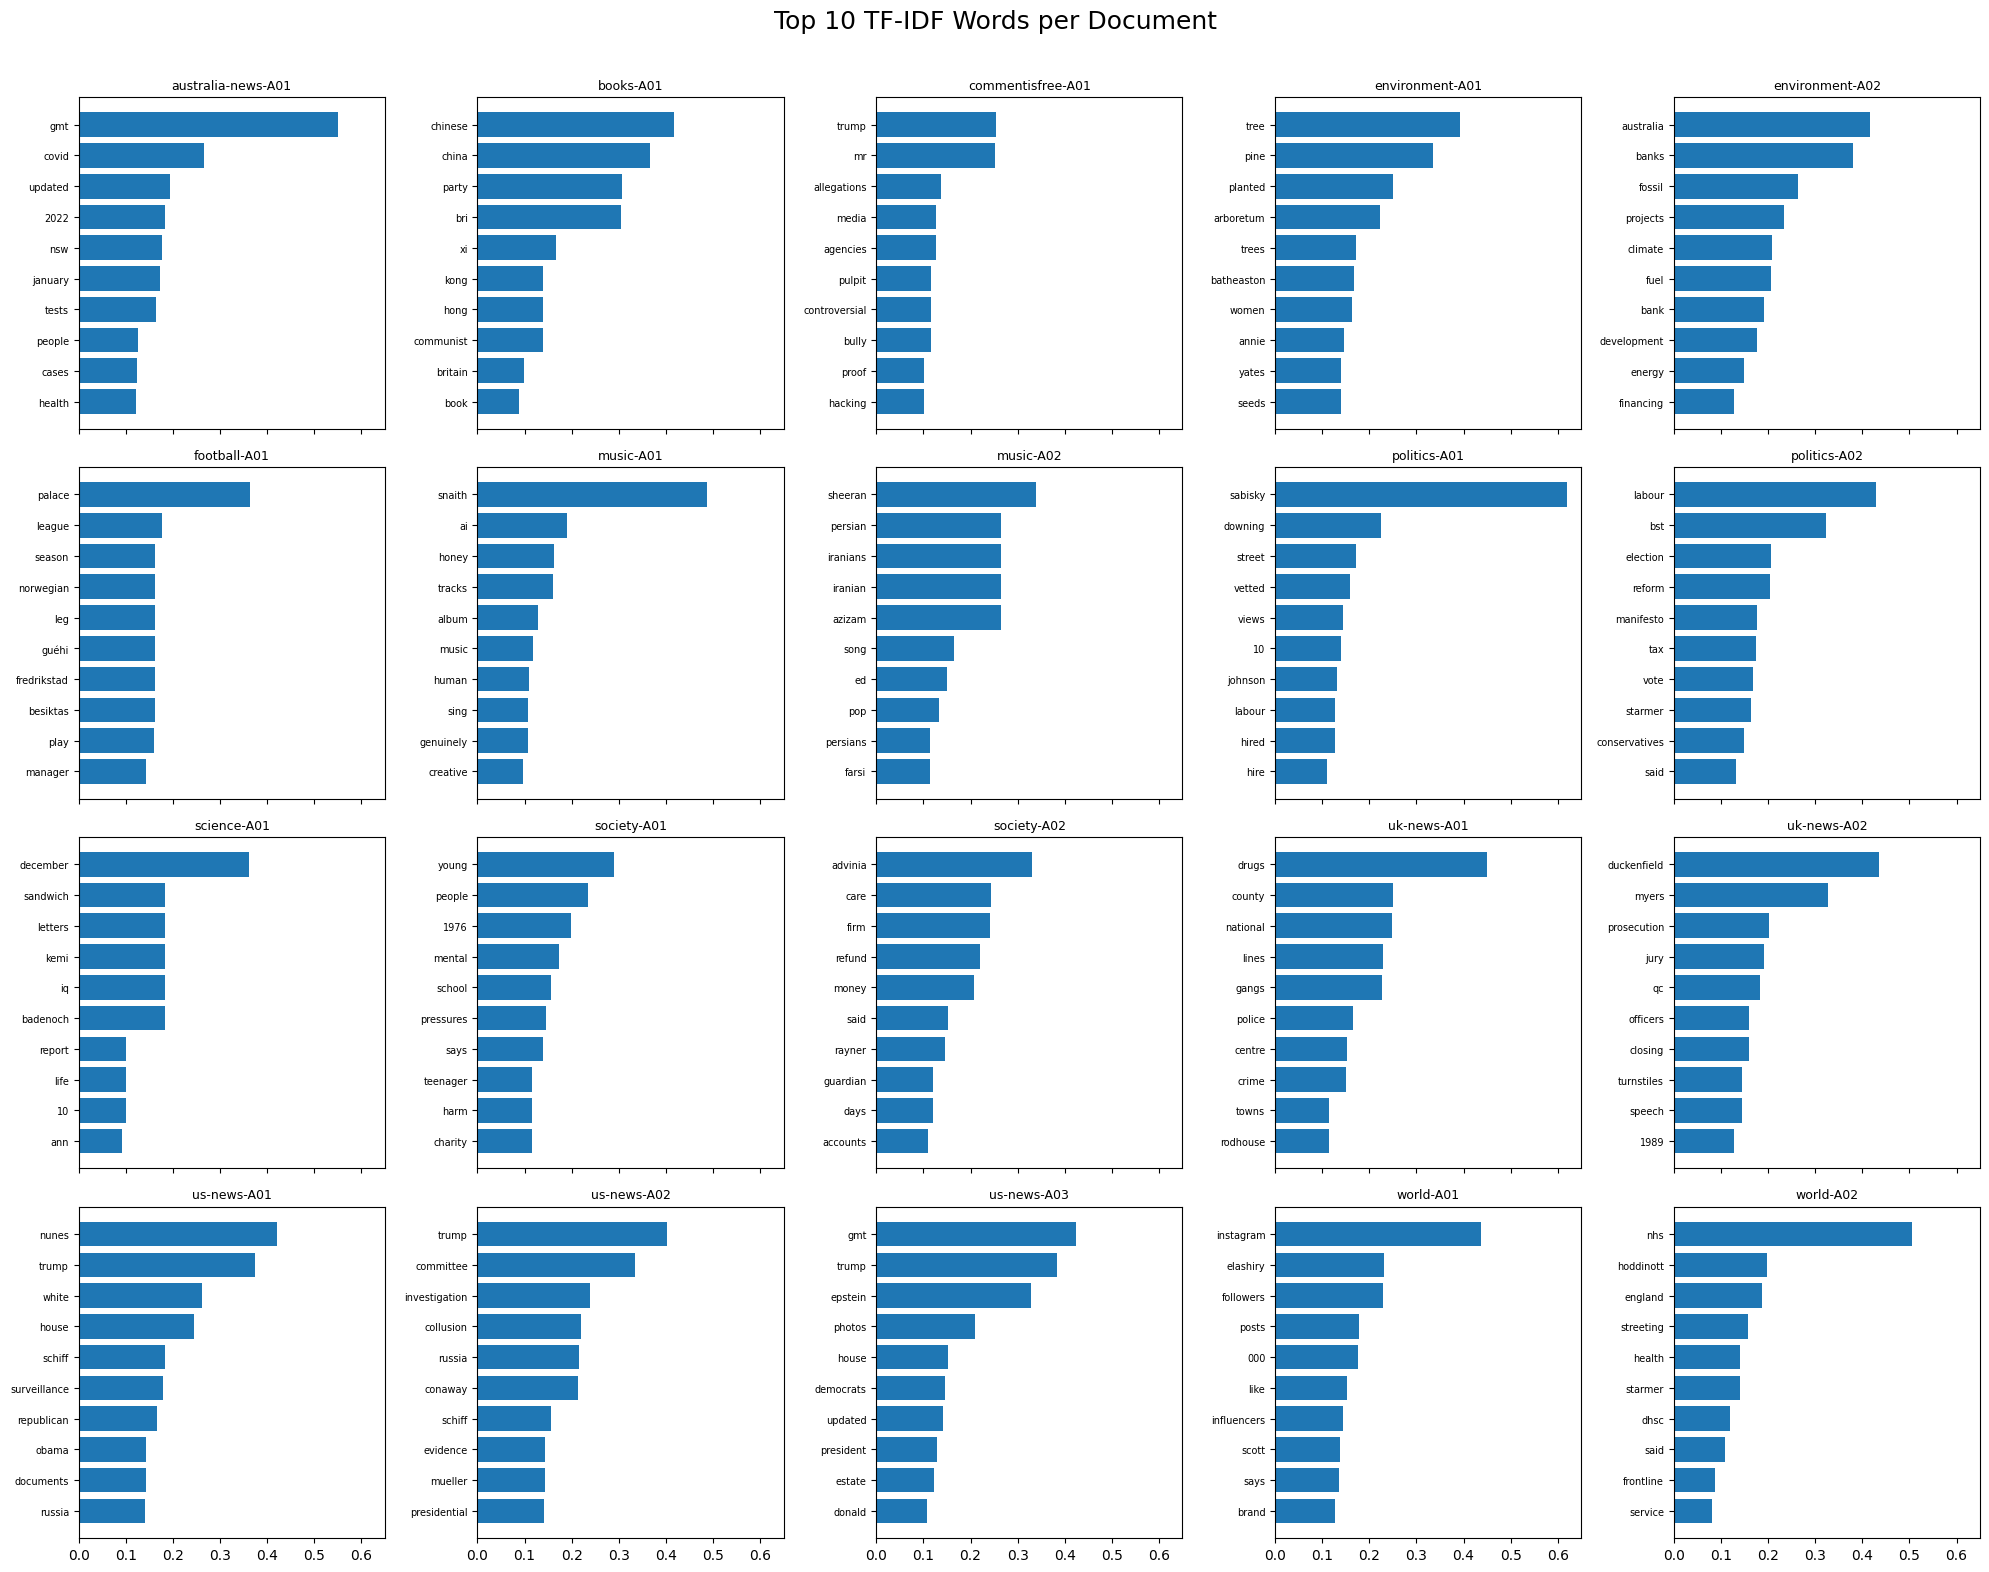

In [ ]:
# top TF-IDF terms by document plot for all articles
import matplotlib.pyplot as plt
import math

docs = tfidf_df.index
n_docs = len(docs)

ncols = 5
nrows = math.ceil(n_docs / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 16), sharex=True)

axes = axes.flatten()

global_max = tfidf_df.apply(lambda row: row.nlargest(10).max(), axis=1).max()

for ax, doc_id in zip(axes, docs):
    top10 = tfidf_df.loc[doc_id].nlargest(10).sort_values()

    ax.barh(top10.index, top10.values)
    ax.set_title(f"{doc_id}", fontsize=9)
    ax.tick_params(axis="y", labelsize=7)
    ax.set_xlim(0, global_max * 1.05)

for i in range(n_docs, len(axes)):
    fig.delaxes(axes[i])

fig.suptitle("Top 10 TF-IDF Words per Document", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

Upon review of this sample's top 10 TF-IDF words per document, we observe a selection of words that appear as top TF-IDF terms across documents. These terms include "trump" and "russia" and appear to be shared among "us-news" and the "commentisfree" section article (as previously noted, an Opinion piece). Other top 10 TF-IDF terms do not appear to be shared across documents, indicating that the documents have a diverse vocabulary. Despite all sharing some explicit mention of "artificial intelligence" or "generative AI", there do not appear to be many other shared vocabulary words after stop word removal. The distinctive terms appear to be related to the specific article's topic rather than a shared theme across articles in the corpus. Even among the articles with in the above plot with shared "sectionName" values, there do not appear to be many shared top TF-IDF terms, outside of the "us-news" articles. 

Without the cleaning of the HTML, many of the top 10 TF-IDF words per document were HTML tags and entities. Some of the remaining values in the top 10 for articles such as "australia-news-A01", "science-A01", "politics-A01", and "society-A01" are numbers and years, which could be further removed to limit the top TF-IDF terms per document to only alphabetical words. 

<h3 id="pearson-correlation">Pearson Correlation</h3>


Next, we can calculate the Pearson correlation to determine which document pairs from our sample corpus of 20 articles are most similar. 

In [ ]:
# pearson correlation
# compute correlation across documents
correlation_matrix = tfidf_df.T.corr(method="pearson")

In [229]:
import numpy as np

upper_tri = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

all_pairs = upper_tri.stack()
all_pairs.index.names = ["article_1", "article_2"]
all_pairs = (
    all_pairs.reset_index()
    .rename(columns={0: "pearson_r"})
    .dropna(subset=["pearson_r"])  # remove NaN correlations
    .sort_values("pearson_r", ascending=False)
)

top_5 = all_pairs.head(5)
bottom_5 = all_pairs.tail(5)

print("Top 5:\n", top_5)


Top 5:
               article_1    article_2  pearson_r
316         us-news-A01  us-news-A02   0.453477
17   australia-news-A01  us-news-A03   0.344711
317         us-news-A01  us-news-A03   0.280342
337         us-news-A02  us-news-A03   0.278678
55    commentisfree-A01  us-news-A01   0.169040


The top five most similar article pairs are displayed in the above table. As you can see, the articles published under the "us-news" are similar to each other and to their "australia-news" News section peer. A correlation score of 1 would indicate that that distribution of words in the two articles is identical. Despite these being the top 5 most similar article pairs, the Pearson correlation coefficients range from ~0.17 to ~0.45. These are overall not very high correlation coefficients, indicating that these article pairs are not very similar at all. 

In [230]:
print("\nBottom 5:\n", bottom_5)


Bottom 5:
               article_1     article_2  pearson_r
129           music-A01  politics-A02  -0.015039
6    australia-news-A01     music-A01  -0.015854
133           music-A01   uk-news-A01  -0.015892
134           music-A01   uk-news-A02  -0.016443
110        football-A01   science-A01  -0.016543


The bottom five article pairs are displayed in the above table. These tables have very low Pearson correlation coefficients, indicating that they are not similar. These most dissimilar article pairs are from topics like music and politics or football and science that we would not expect to have a large amount of shared vocabulary. 

The plot below again displays the Pearson correlation values, and clusters them with the highest values in the top left corner of the heatmap. As you can see, the news and "commentisfree" (Opinion) section articles appear to be the most similar. 

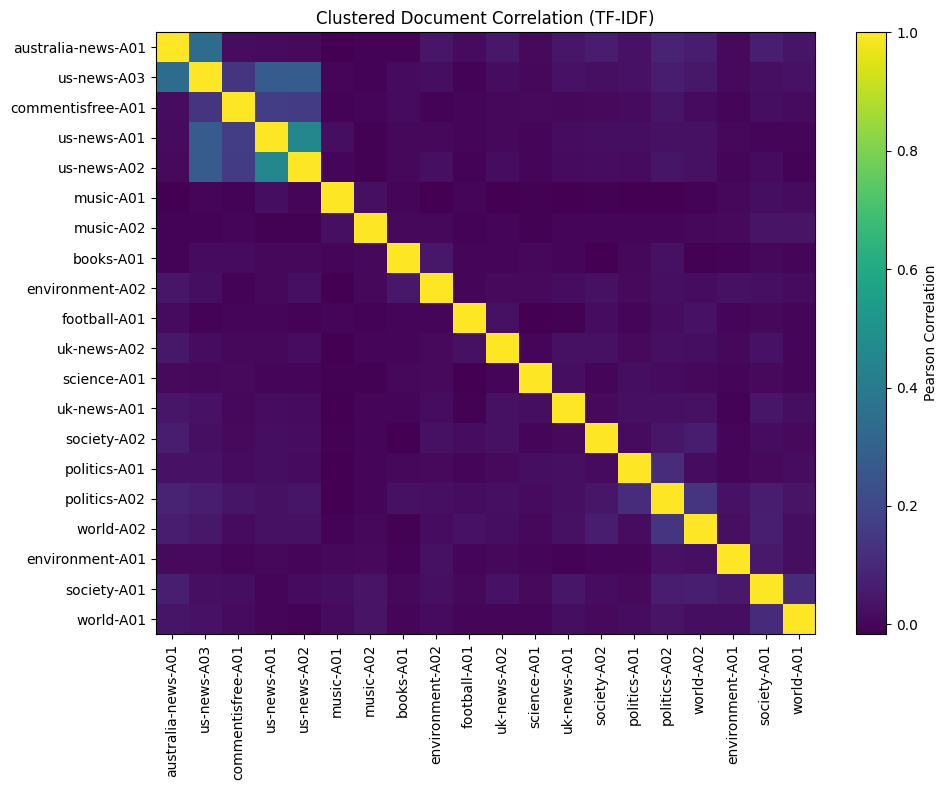

In [198]:
from scipy.cluster.hierarchy import linkage, leaves_list
import numpy as np

corr = correlation_matrix.astype(float)
# Hierarchical clustering
linked = linkage(corr, method="average")
order = leaves_list(linked)

corr_sorted = corr.iloc[order, order]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_sorted.values, aspect="auto")

plt.colorbar(im).set_label("Pearson Correlation")

sorted_labels = corr_sorted.index.astype(str)

ax.set_xticks(np.arange(len(sorted_labels)))
ax.set_yticks(np.arange(len(sorted_labels)))

ax.set_xticklabels(sorted_labels, rotation=90)
ax.set_yticklabels(sorted_labels)

ax.set_title("Clustered Document Correlation (TF-IDF)")
plt.tight_layout()
plt.show()

<h3 id="syntactic-complexity-measures">Syntactic Complexity Measures</h3>


Finally, we can analyze our sample 20 article subset of the overall corpus by multiple syntactic complexity measures. Further analysis could be performed by analyzing these articles by author to understand an author's particular writing style. Hoewever, because that was not a parameter that was available via the Guardian API, we can compare our sample subset directly along multiple dimensions including mean length of sentence, clauses per sentence, subordination, coordination, and phrasal complexity.

In [213]:
# syntactic complexity measures
# load model
import spacy
import pandas as pd
import numpy as np

nlp = spacy.load("en_core_web_sm")

In [ ]:
def compute_syntactic_profile(text, doc_label="doc"):

    doc = nlp(text)

    sentence_stats = []

    for sent in doc.sents:
        tokens = list(sent)

        token_count = len(tokens)

        # Clause approximation
        clauses = sum(1 for t in tokens if t.pos_ in ["VERB", "AUX"])

        # Dependent clauses
        dep_clauses = sum(
            1 for t in tokens if t.dep_ in ["advcl", "ccomp", "xcomp", "acl", "relcl"]
        )

        # Coordination
        coord = sum(1 for t in tokens if t.dep_ == "cc")

        # Complex nominals
        complex_nominals = sum(
            1 for t in tokens if t.dep_ in ["compound", "amod", "nmod", "appos"]
        )

        sentence_stats.append(
            {
                "tokens": token_count,
                "clauses": clauses,
                "dep_clauses": dep_clauses,
                "coord": coord,
                "complex_nominals": complex_nominals,
                "text": sent.text,
            }
        )

    sent_df = pd.DataFrame(sentence_stats)

    if len(sent_df) == 0:
        return None

    MLS = sent_df["tokens"].mean()

    total_sent = len(sent_df)
    total_clauses = sent_df["clauses"].sum()

    if total_clauses == 0:
        total_clauses = np.nan

    C_per_S = sent_df["clauses"].mean()

    DC_per_C = sent_df["dep_clauses"].sum() / total_clauses
    DC_per_S = sent_df["dep_clauses"].sum() / total_sent

    Coord_per_C = sent_df["coord"].sum() / total_clauses
    Coord_per_S = sent_df["coord"].sum() / total_sent

    CN_per_C = sent_df["complex_nominals"].sum() / total_clauses
    CN_per_S = sent_df["complex_nominals"].sum() / total_sent

    profile = pd.DataFrame(
        [
            {
                "doc": doc_label,
                "MLS": round(MLS, 2),
                "Clauses_per_Sentence": round(C_per_S, 2),
                "Dep_Clauses_per_Clause": round(DC_per_C, 2),
                "Dep_Clauses_per_Sentence": round(DC_per_S, 2),
                "Coord_per_Clause": round(Coord_per_C, 2),
                "Coord_per_Sentence": round(Coord_per_S, 2),
                "Complex_Nominals_per_Clause": round(CN_per_C, 2),
                "Complex_Nominals_per_Sentence": round(CN_per_S, 2),
            }
        ]
    )

    return profile, sent_df

In [257]:
from IPython.display import display, HTML

profiles = []

for _, row in df.iterrows():
    profile, _ = compute_syntactic_profile(row["clean_body"], doc_label=row["short_id"])
    profiles.append(profile)

syntactic_table = pd.concat(profiles, ignore_index=True)

display(HTML(syntactic_table.to_html()))

,doc,MLS,Clauses_per_Sentence,Dep_Clauses_per_Clause,Dep_Clauses_per_Sentence,Coord_per_Clause,Coord_per_Sentence,Complex_Nominals_per_Clause,Complex_Nominals_per_Sentence
0,australia-news-A01,25.15,4.15,0.37,1.56,0.14,0.60,0.83,3.46
1,books-A01,27.28,3.76,0.35,1.33,0.33,1.24,1.09,4.09
2,commentisfree-A01,26.19,4.59,0.44,2.03,0.20,0.91,0.60,2.75
3,environment-A01,28.91,4.74,0.45,2.13,0.15,0.72,0.67,3.15
4,environment-A02,28.69,4.22,0.43,1.81,0.23,0.97,1.18,4.97
5,football-A01,35.90,6.14,0.45,2.76,0.08,0.52,0.77,4.72
6,music-A01,31.78,4.81,0.34,1.62,0.29,1.41,0.98,4.72
7,music-A02,29.61,4.53,0.39,1.75,0.25,1.14,0.82,3.72
8,politics-A01,32.21,6.29,0.42,2.64,0.16,1.00,0.55,3.43
9,politics-A02,29.29,4.94,0.42,2.09,0.12,0.62,0.75,3.72


As we can see in the above table of all 20 articles with corresponding syntactic complexity measures, the articles are similar in complexity. The mean length of sentences appears to range from approximately 25 words to approximately 35 words, with some observations above and below this range. The number of clauses per sentence is around 4-5. 

When we look at subordination through the lens of dependent clause per clause, we see that there are moderate values, indicating some use of hierarchical, embedded dependent clauses that can be read as more complex syntax. There are around 1.5-2 dependent clauses per sentence, indicating a moderate amount of subordination per sentence but less than what we would expect from literature. Looking at coordination, or measuring how the clauses are linked, we see lower scores, and the coordination per sentence also appears to be low. Finally, the phrasal complexity, which is measured by complex nominals per clauses and complex nominals per sentence appears to be generally low when compared to the Week 05 class example. 

Overall, these measures of syntactical complexity appear in lines of what can be expected. *The Guardian* publishes articles for a public audience, and must maintain a certain level of legibility for a wider audience than could be expected for a technical domain-specific corpus or an audience that is well-versed in classical literature. 

For further comparison, I re-computed the same syntactical measures but retained the search term collected in the dataset.

In [258]:
pd.set_option("display.width", None)  # no line wrapping
from IPython.display import display, HTML


def compute_syntactic_profile_withsearchterm(text, doc_label="doc", search_term=None):
    doc = nlp(text)

    sentence_stats = []

    for sent in doc.sents:
        tokens = list(sent)
        token_count = len(tokens)

        # Clause approximation: verbs + auxiliaries
        clauses = sum(1 for t in tokens if t.pos_ in ["VERB", "AUX"])

        # Dependent clauses approximation
        dep_clauses = sum(
            1 for t in tokens if t.dep_ in ["advcl", "ccomp", "xcomp", "acl", "relcl"]
        )

        # Coordination
        coord = sum(1 for t in tokens if t.dep_ == "cc")

        # Complex nominals
        complex_nominals = sum(
            1 for t in tokens if t.dep_ in ["compound", "amod", "nmod", "appos"]
        )

        sentence_stats.append(
            {
                "tokens": token_count,
                "clauses": clauses,
                "dep_clauses": dep_clauses,
                "coord": coord,
                "complex_nominals": complex_nominals,
                "text": sent.text,
            }
        )

    sent_df = pd.DataFrame(sentence_stats)

    if len(sent_df) == 0:
        return None, None

    MLS = sent_df["tokens"].mean()
    total_sent = len(sent_df)
    total_clauses = sent_df["clauses"].sum()
    if total_clauses == 0:
        total_clauses = np.nan

    C_per_S = sent_df["clauses"].mean()
    DC_per_C = sent_df["dep_clauses"].sum() / total_clauses
    DC_per_S = sent_df["dep_clauses"].sum() / total_sent
    Coord_per_C = sent_df["coord"].sum() / total_clauses
    Coord_per_S = sent_df["coord"].sum() / total_sent
    CN_per_C = sent_df["complex_nominals"].sum() / total_clauses
    CN_per_S = sent_df["complex_nominals"].sum() / total_sent

    profile = pd.DataFrame(
        [
            {
                "doc": doc_label,
                "search_term": search_term,
                "MLS": round(MLS, 2),
                "Clauses_per_Sentence": round(C_per_S, 2),
                "Dep_Clauses_per_Clause": round(DC_per_C, 2),
                "Dep_Clauses_per_Sentence": round(DC_per_S, 2),
                "Coord_per_Clause": round(Coord_per_C, 2),
                "Coord_per_Sentence": round(Coord_per_S, 2),
                "Complex_Nominals_per_Clause": round(CN_per_C, 2),
                "Complex_Nominals_per_Sentence": round(CN_per_S, 2),
            }
        ]
    )

    return profile, sent_df


# Apply to each document
profiles = []
for _, row in df.iterrows():
    profile, _ = compute_syntactic_profile_withsearchterm(
        row["clean_body"],
        doc_label=row["short_id"],
        search_term=row["search_term"],
    )
    if profile is not None:
        profiles.append(profile)

syntactic_table_withsearchterm = pd.concat(profiles, ignore_index=True)
# print(syntactic_table_withsearchterm)


display(HTML(syntactic_table_withsearchterm.to_html()))

,doc,search_term,MLS,Clauses_per_Sentence,Dep_Clauses_per_Clause,Dep_Clauses_per_Sentence,Coord_per_Clause,Coord_per_Sentence,Complex_Nominals_per_Clause,Complex_Nominals_per_Sentence
0,australia-news-A01,generative AI,25.15,4.15,0.37,1.56,0.14,0.60,0.83,3.46
1,books-A01,generative AI,27.28,3.76,0.35,1.33,0.33,1.24,1.09,4.09
2,commentisfree-A01,artificial intelligence,26.19,4.59,0.44,2.03,0.20,0.91,0.60,2.75
3,environment-A01,generative AI,28.91,4.74,0.45,2.13,0.15,0.72,0.67,3.15
4,environment-A02,artificial intelligence,28.69,4.22,0.43,1.81,0.23,0.97,1.18,4.97
5,football-A01,artificial intelligence,35.90,6.14,0.45,2.76,0.08,0.52,0.77,4.72
6,music-A01,generative AI,31.78,4.81,0.34,1.62,0.29,1.41,0.98,4.72
7,music-A02,generative AI,29.61,4.53,0.39,1.75,0.25,1.14,0.82,3.72
8,politics-A01,artificial intelligence,32.21,6.29,0.42,2.64,0.16,1.00,0.55,3.43
9,politics-A02,generative AI,29.29,4.94,0.42,2.09,0.12,0.62,0.75,3.72


Grouping these articles by their search term, we can further analyze to determine if there are any particular differences. 

In [242]:
# Example: mean syntactic measures by search_term
syntactic_table_withsearchterm.groupby("search_term").mean(numeric_only=True)

,MLS,Clauses_per_Sentence,Dep_Clauses_per_Clause,Dep_Clauses_per_Sentence,Coord_per_Clause,Coord_per_Sentence,Complex_Nominals_per_Clause,Complex_Nominals_per_Sentence
search_term,,,,,,,,
artificial intelligence,30.771,4.991,0.422,2.114,0.159,0.789,0.816,4.011
generative AI,27.670,4.407,0.396,1.755,0.198,0.866,0.806,3.553


Overall, the mean length of sentences appears to be slightly higher for articles that explicitly mentioned "artificial intelligence". However, among the other measures of syntactic complexity, these two types of articles did not appear to have significant variation. This is likely due to the nature of how the search was performed. There does not appear to be any intrinsic meaning to the keyword search term included in the article, and further analysis by other dimensions would be required to draw any conclusions about the difference between articles that mention "artificial intelligence" versus "generative AI". The two search terms are also not mutually exclusive in the content of the articles and may appear across both types, adding further noise to the analysis. 

In [192]:
# close connection to DuckDB
con.close()

<h2 id="synthesis-of-findings">Synthesis of Findings</h2>


Overall, this corpus of over 24,000 articles represents a robust corpus of articles concerning artificial intelligence and generative AI. The lack of missingness of data makes it feasible for my purpose of building a query system with RAG functionality that is supplemented by additional feature engineering through Named Entity Recognition.

The analysis of distinctive words using TF-IDF indicates that there are shared distinctive words among articles published under the same section (such as "News"), but that there is not a broad set of shared vocabulary among the wider universe of articles that mention artificail intelligence and generative AI in our corpus. The Pearson correlation analysis corroborated this finding, showing that articles from the News section were similar but overall there were low levels of similarity between articles in the sampled subset of the corpus. Many of the articles that write about artificial intelligence and generative AI come from the news and politics desks of *The Guardian*, particularly in news articles regarding the United States and the United Kingdom. It is likely that the novelty of artificial intelligence and its rapid development leads to articles concerning AI being more likely to be published under the "News" section of *The Guardian*. If so, a deeper analysis of only "News" articles in the corpus may uncover latent themes. Finally, an analysis of the syntactic complexity found that the articles were less syntactically complex than the older examples of writing on political economy that we reviewed through the course tutorials. Since these are articles written for a public audience, this finding is unsurprising. 

Ultimately, while the corpus appears sufficient for the development of my intended NER + RAG tool, the types of questions it can answer require careful scaffolding. It may be more fruitful to analyze shared themes across articles published under the same pillar or section rather than conducting analysis with the assumption that any articles that mention artificial intelligence or generative AI have certain shared themes. Further research questions could be developed by framing questions around the general coverage of artificial intelligence and generative AI by British news media (here exemplified by *The Guardian*) or analysis of how these technologies intersect with other facets of society, politics, and culture. Since few article pairs appear to be very closely related, pairwise comparisons of themes or content do not appear to be fruitful. 

<h3 id="limitations-and-future-work">Limitations and Future Work</h3>

This analysis represents a limited exploration into the Guardian's overall corpus of news articles and publicly available content.  This analysis was limited to querying the Guardian API tool with the search terms "artificial intelligence" and "generative AI", although it is likely that some articles may have been missed that contain discussion of these and similar technologies but did not explicitly contain these keyword search terms. As previously mentioned, much of this analsis only looked at a random sample of the large corpus. Since I only sampled 10 articles for each search term, there may be different findings when comparing articles by different dimensions (authors, year published, sectionName). Although some this analysis compared findings by search term, it is not yet clear that the decision to use "artificial intelligence" versus "generative AI" when writing about these technologies is accompanied by an intent to tell a different narrative or approach these technologies from a different paradigm. 

As I further develop this project, I plan to implement named entity recognition with a BERT model, saving features such as the names of researchers, product developers, CEOs, companies, and specific AI products. This will allow users to query the application, and the underlying corpus by these different features. The existence of these features and their incorporation into the data pipeline will also allow for retrieval augmented generation with a large language model to permit to ask questions about artificial intelligence using natural language that can then be answered through the retrieval of information from the articles in the corpus.

<h3 id="appendix">Appendix</h3>

Documentation:
- Guardian API Documentation: https://open-platform.theguardian.com/documentation/
- Glasglow Information Retrieval Group List of English Stop Words: http://ir.dcs.gla.ac.uk/resources/linguistic_utils/stop_words

References

Haenlein, Michael, and Andreas Kaplan. “A Brief History of Artificial Intelligence: On the Past, Present, and Future of Artificial Intelligence.” California Management Review, vol. 61, no. 4, 17 July 2019, pp. 5–14. Sage Journals, https://doi.org/10.1177/0008125619864925.
https://www.forbes.com/sites/bernardmarr/2023/05/19/a-short-history-of-chatgpt-how-we-got-to-where-we-are-today/

Marr, Bernard. “A Short History of ChatGPT: How We Got to Where We Are Today.” Forbes, 19 May 2023, www.forbes.com/sites/bernardmarr/2023/05/19/a-short-history-of-chatgpt-how-we-got-to-where-we-are-today/.